In [2]:
import numpy as np
from array import *
import matplotlib.pyplot as plt
import math
import time
import dunestyle.matplotlib as dunestyle

DUNE plot style enabled


/home/leoperes/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [9]:
path = "/home/leoperes/Desktop/UpperLimitCodeBDMv4/UpperLimitCodeBDM/Optimization/Optimization_DefaultNuclearModel_final/generated/20260511_204444/"


In [36]:
CosSun_b1p1_m10 = np.load(path + "CosSun_m10_b1p1.npy", allow_pickle=True)
CosSun_b1p5_m10 = np.load(path + "CosSun_m10_b1p5.npy", allow_pickle=True)
CosSun_b10_m10 = np.load(path + "CosSun_m10_b10.npy", allow_pickle=True)
CosSun_Atm = np.load(path + "CosSun_Atm_hA_BR.npy", allow_pickle=True)

In [37]:
np.size(CosSun_b1p1_m10), np.size(CosSun_b1p5_m10), np.size(CosSun_b10_m10), np.size(CosSun_Atm)

(9450, 72025, 90337, 375941)

In [40]:
def Take10krandomevts(array):
    if len(array) > 9000:
        return np.random.choice(array, size=9000, replace=False)
    else:
        return array

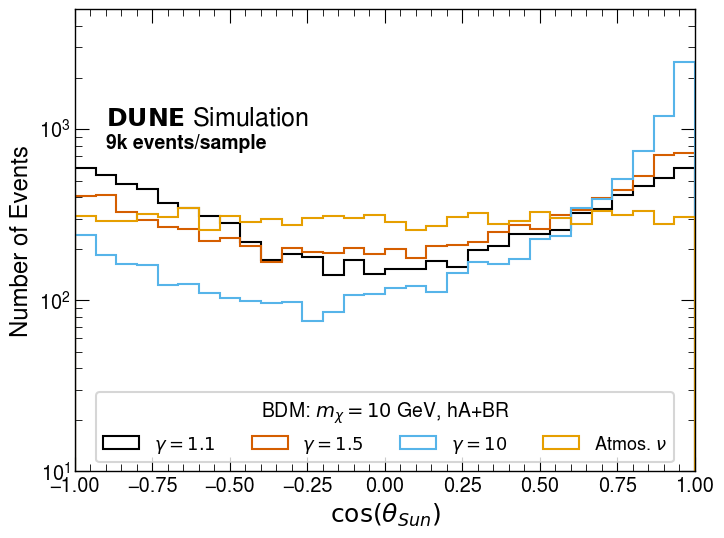

In [63]:
#bestCutRight=0.872
plt.figure(figsize=(8,6))
plt.xlabel(r'$\cos (\theta_{Sun})$', fontsize = 18)
plt.xlim([-1,1])
plt.ylim([1e1,0.5e4])
plt.yscale('log')
h1, x1, _ = plt.hist(Take10krandomevts(CosSun_b1p1_m10), bins= 30, density=False, label=r'$\gamma = 1.1$', histtype='step',lw =1.5, ls='-')
h2, x2, _ = plt.hist(Take10krandomevts(CosSun_b1p5_m10), bins= 30, density=False, label=r'$\gamma = 1.5$', histtype='step', lw =1.5, ls='-')
h3, x3, _ = plt.hist(Take10krandomevts(CosSun_b10_m10), bins= 30, density=False, label=r'$\gamma = 10$', histtype='step', lw =1.5, ls= '-')
h4, x4, _ = plt.hist(Take10krandomevts(CosSun_Atm), bins= 30, density=False, label=r'Atmos. $\nu$', histtype='step', lw =1.5, ls= '-')
#plt.xlabel(r'$\cos(\theta_{\Sun})$')
h = max(h1.max(),h2.max(),h3.max(),h4.max())
dunestyle.Simulation(x=0.05,y=0.75)
#plt.vlines(bestCutRight, 0, 1e6, colors='darkolivegreen', linestyles='solid',lw=2)
#plt.plot(bestCutRight+0.06, h.max()*2, marker=r'$\rightarrow$', markersize=20,markerfacecolor='darkolivegreen',markeredgecolor="darkolivegreen")
plt.ylabel('Number of Events')
plt.text(0.05, 0.7, '9k events/sample', transform=plt.gca().transAxes, fontsize=14, fontweight='bold')
plt.legend(frameon=True, title = r'BDM: $m_\chi=10$ GeV, hA+BR',loc='lower center', fontsize=13, title_fontsize=14, ncols=4)
plt.savefig('all_cos_'+str(time.strftime("%Y%m%d"))+'_v2.pdf', format='pdf', dpi=600)
plt.show()